# ENSO Exploratory Data Analysis

This notebook performs exploratory data analysis of the merged ENSO dataset constructed from NOAA TAO/TRITON observations.

The analysis focuses on the Eastern and Western Pacific representations used throughout this study:

- $T_E$: Eastern Pacific SST
- $T_W$: Western Pacific SST
- $h_E$: Eastern Pacific Z20
- $h_W$: Western Pacific Z20

The objectives are:

1. Explore statistical properties of the variables.
2. Investigate relationships between SST and Z20.
3. Examine temporal dependencies and lead-lag behaviour.
4. Identify dominant oscillatory patterns.
5. Generate insights to guide subsequent NGRC modelling.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import periodogram, find_peaks

In [2]:
DATA = Path("../data")

PROCESS = DATA / "processed"

OUTPUT_DIR = Path("../outputs")

IMAGE_DIR = OUTPUT_DIR / "images" / "enso_eda"

IMAGE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

In [4]:
enso_dataset = pd.read_csv(
    PROCESS / "enso_dataset.csv",
    parse_dates=["date"]
)
print(f"Shape : {enso_dataset.shape}")

enso_dataset.head()

Shape : (17134, 5)


,date,west_t,west_h,east_t,east_h
0,1979-01-20,NaN,NaN,23.793333,70.136667
1,1979-01-21,NaN,NaN,23.936667,65.733333
2,1979-01-22,NaN,NaN,24.056667,63.583333
3,1979-01-23,NaN,NaN,23.810000,62.170000
4,1979-01-24,NaN,NaN,24.003333,67.836667


## Data Information

In [5]:
enso_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 17134 entries, 0 to 17133
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    17134 non-null  datetime64[us]
 1   west_t  14612 non-null  float64       
 2   west_h  14895 non-null  float64       
 3   east_t  16518 non-null  float64       
 4   east_h  17029 non-null  float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 669.4 KB


In [7]:
missing = (
    enso_dataset
    .isna()
    .sum()
    .to_frame("missing")
)

missing["percentage"] = (
    100*missing["missing"] / len( enso_dataset)
).round(2)

missing

,missing,percentage
date,0,0.00
west_t,2522,14.72
west_h,2239,13.07
east_t,616,3.60
east_h,105,0.61


In [8]:
enso_dataset.describe().T

,count,mean,min,25%,50%,75%,max,std
date,17134,2002-12-27 02:44:38.463873,1979-01-20 00:00:00,1991-04-06 06:00:00,2002-12-27 12:00:00,2014-09-18 18:00:00,2026-06-17 00:00:00,NaN
west_t,14612.0,28.877641,25.72875,28.332222,29.01225,29.52,30.92,0.8542
west_h,14895.0,166.982689,114.427778,158.624167,168.07875,176.89,214.61,15.061736
east_t,16518.0,24.913465,18.66,23.487917,24.898056,26.311071,29.794444,1.885351
east_h,17029.0,61.447016,1.46,47.6,59.181429,72.42,155.365,20.227136


### Time Series Overview

In [72]:
def plot_sst(df, name):

    plt.figure(figsize=(18, 6))

    plt.plot(
        df["date"],
        df["east_t"],
        color="orange",
        linestyle="--",
        linewidth=1.5,
        label=r"$T_E$"
    )

    plt.plot(
        df["date"],
        df["west_t"],
        color="red",
        linewidth=1.5,
        alpha=0.7,
        label=r"$T_W$"
    )

    plt.title("Eastern and Western Pacific SST")

    plt.xlabel("Date")

    plt.ylabel("SST (°C)")

    plt.legend()

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        IMAGE_DIR / f"east_west_sst_{name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

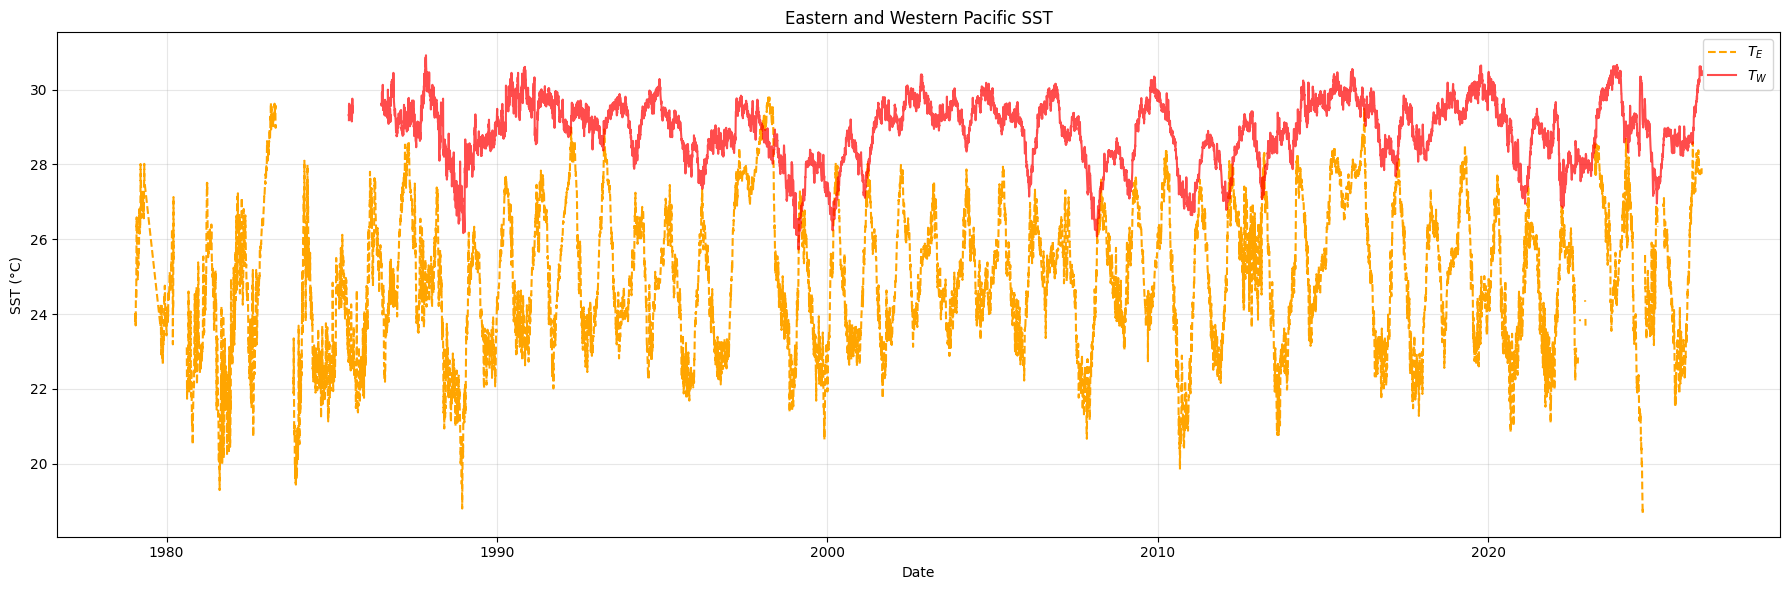

In [73]:
plot_sst(enso_dataset, "full")

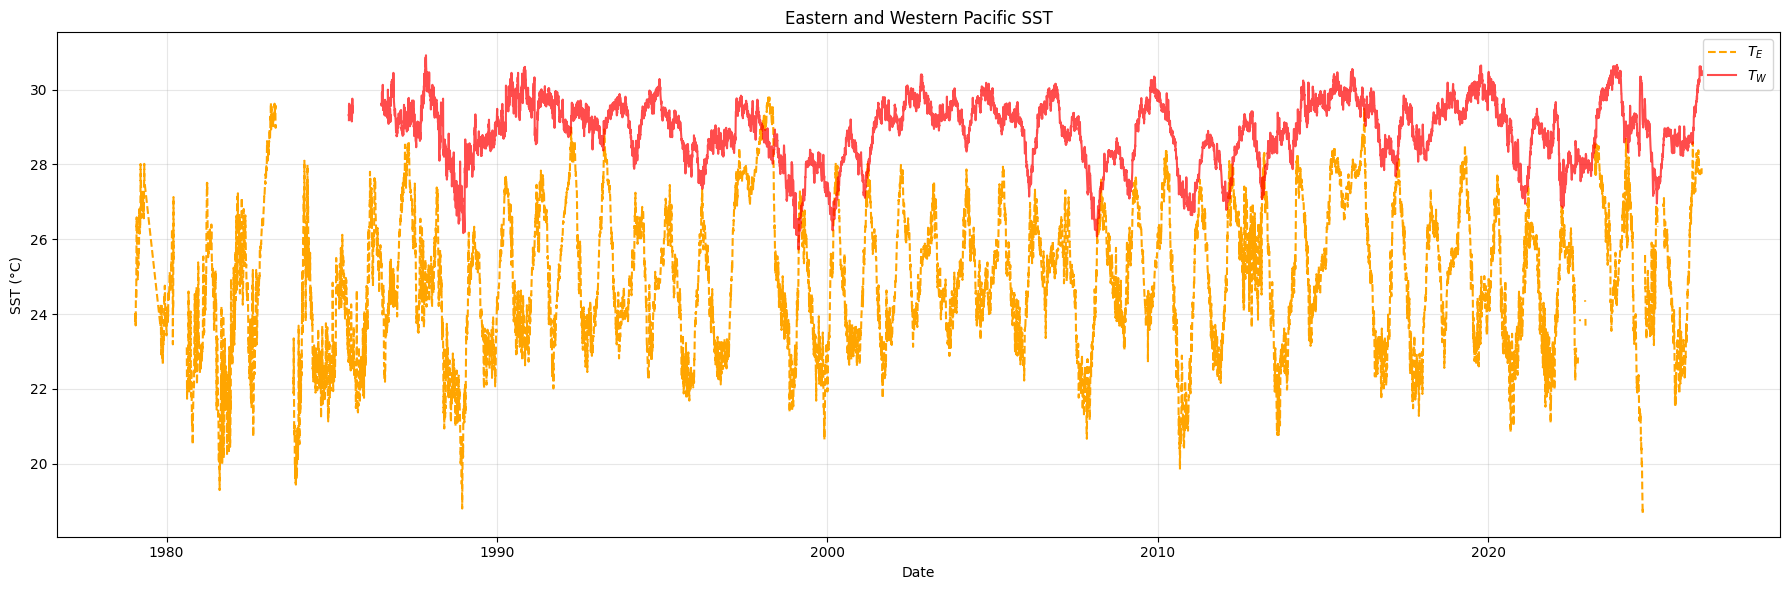

In [16]:
plt.figure(figsize=(18, 6))

plt.plot(
    enso_dataset["date"],
    enso_dataset["east_t"],
    color="orange",
    linestyle="--",
    linewidth=1.5,
    label=r"$T_E$"
)

plt.plot(
    enso_dataset["date"],
    enso_dataset["west_t"],
    color="red",
    linewidth=1.5,
    label=r"$T_W$",
    alpha = 0.7
)

plt.title("Eastern and Western Pacific SST")

plt.xlabel("Date")

plt.ylabel("SST (°C)")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "east_west_sst.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Z20 Time Series Overview

In [75]:
def plot_z20(df, name):

    plt.figure(figsize=(18, 6))

    plt.plot(
        df["date"],
        df["east_h"],
        linestyle="--",
        linewidth=1.5,
        label=r"$h_E$"
    )

    plt.plot(
        df["date"],
        df["west_h"],
        color="blue",
        linewidth=1.5,
        alpha=0.7,
        label=r"$h_W$"
    )

    plt.title("Eastern and Western Pacific Z20")

    plt.xlabel("Date")

    plt.ylabel("Z20 (m)")

    plt.legend()

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        IMAGE_DIR / f"east_west_h_{name}.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()
    

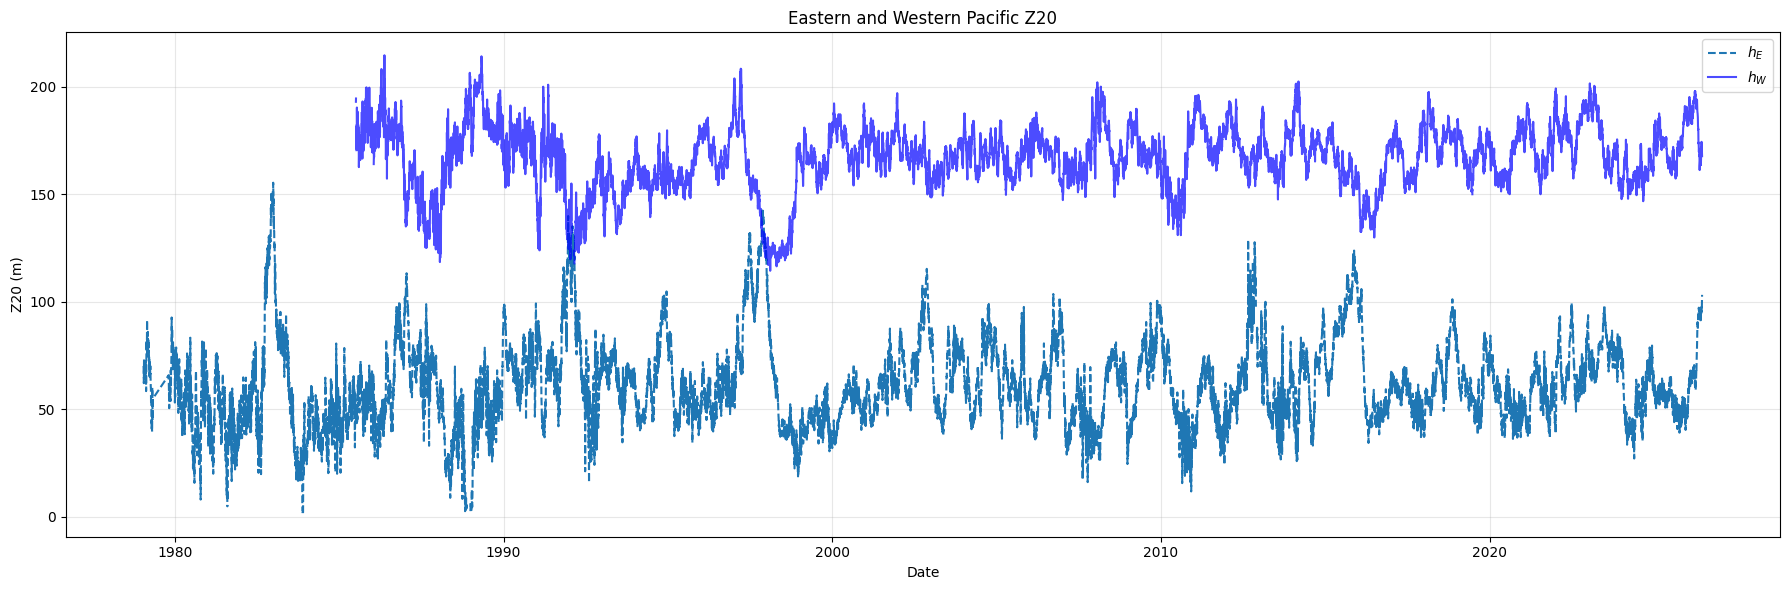

In [76]:
plot_z20(enso_dataset, "full")


In [69]:
for col in enso_dataset.columns:

    first = enso_dataset.loc[enso_dataset[col].notna(), "date"].min()

    last = enso_dataset.loc[enso_dataset[col].notna(), "date"].max()

    print(f"{col}: {first} -> {last}")


date: 1979-01-20 00:00:00 -> 2026-06-17 00:00:00
west_t: 1985-07-06 00:00:00 -> 2026-06-17 00:00:00
west_h: 1985-07-06 00:00:00 -> 2026-06-17 00:00:00
east_t: 1979-01-20 00:00:00 -> 2026-06-17 00:00:00
east_h: 1979-01-20 00:00:00 -> 2026-06-17 00:00:00


In [129]:
enso_common = ( enso_dataset[enso_dataset["date"] >= "1986-07-04"].reset_index(drop=True))

In [130]:
enso_common.loc[
    (enso_common["date"] >= "1985-08-22")
    &
    (enso_common["date"] <= "1986-07-04")
].isna().sum()

date      0
west_t    0
west_h    0
east_t    0
east_h    0
dtype: int64

In [163]:
enso_roll7 = enso_common.copy()

enso_roll7.iloc[:, 1:] = (
    enso_roll7.iloc[:, 1:]
    .rolling(
        window=7,
        center=True,
        min_periods=1
    )
    .mean()
)

In [164]:
enso_roll30 = enso_common.copy()

enso_roll30.iloc[:, 1:] = (
    enso_roll30.iloc[:, 1:]
    .rolling(
        window=30,
        center=True,
        min_periods=1
    )
    .mean()
)

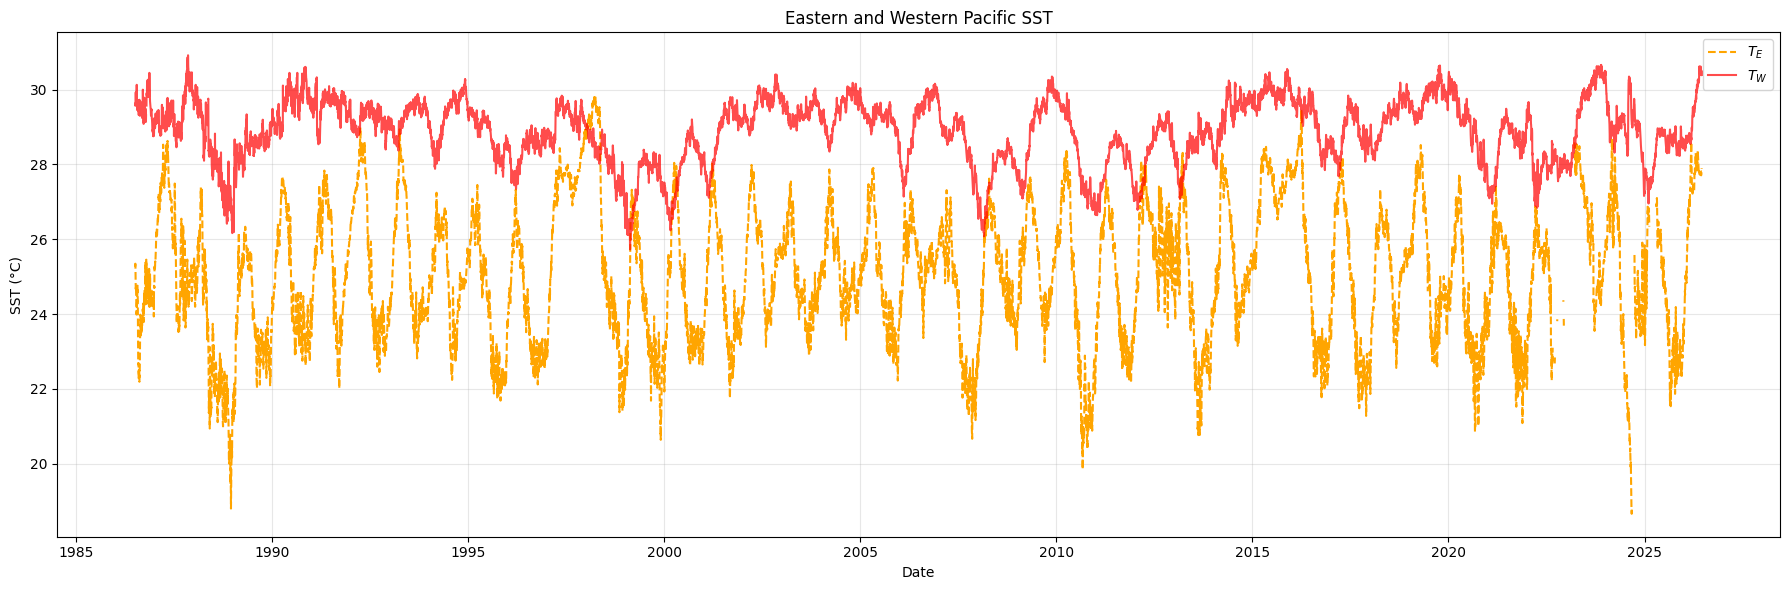

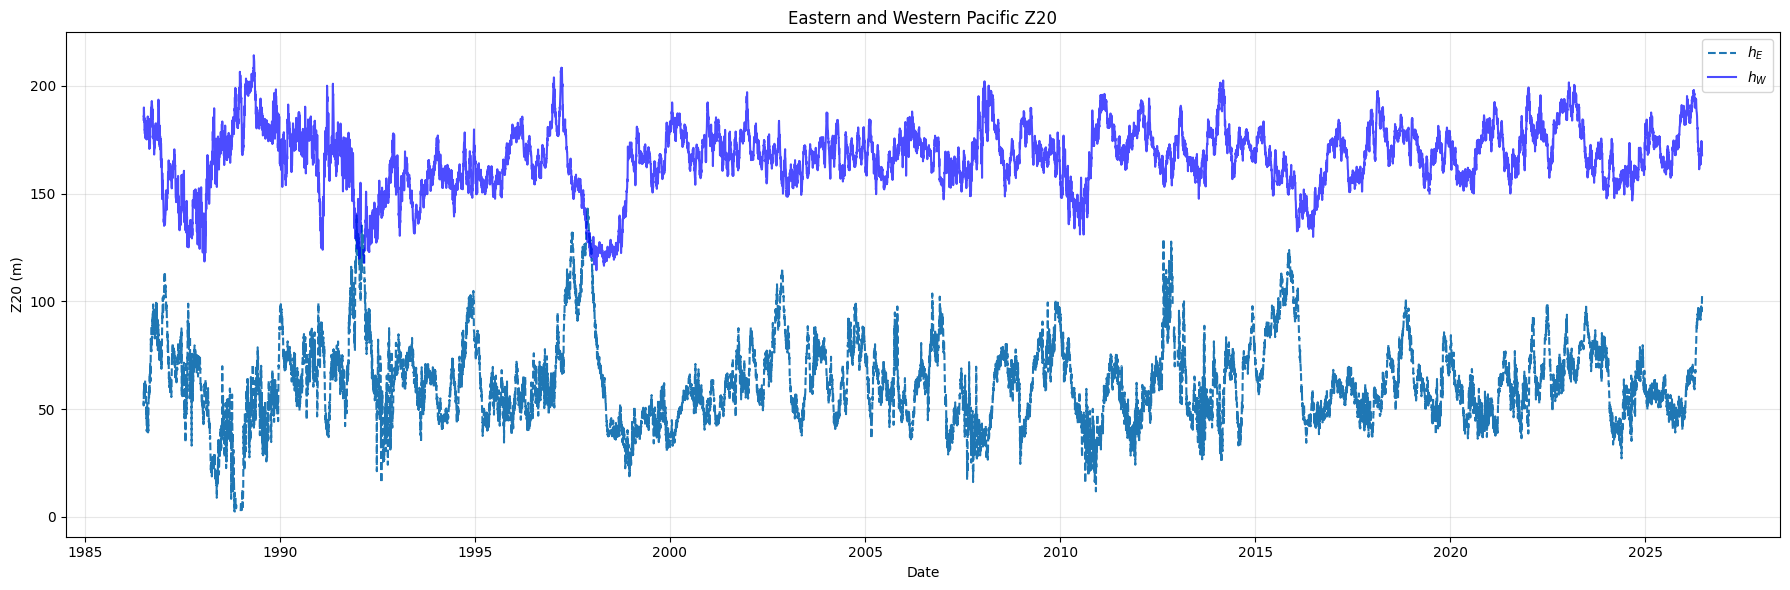

In [131]:
plot_sst(enso_common, "common")
plot_z20(enso_common, "common")

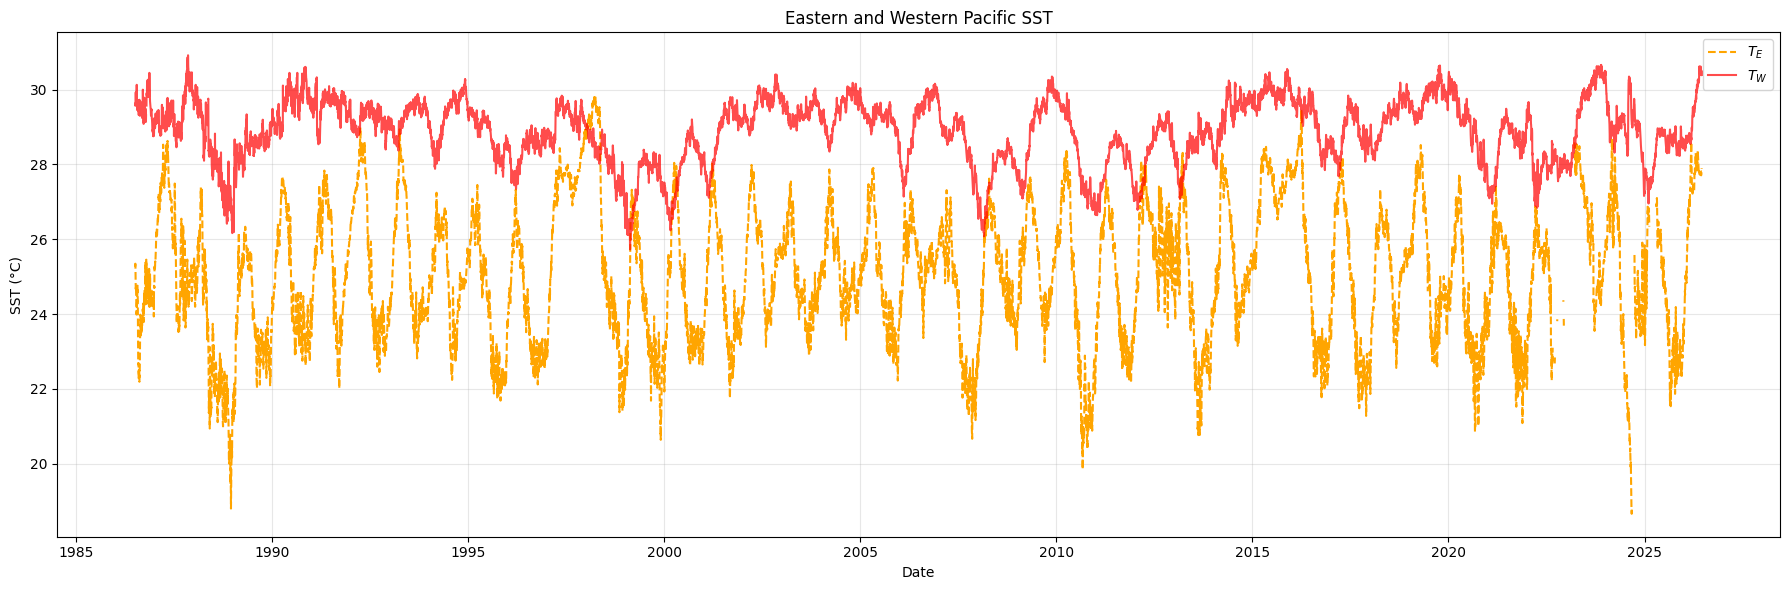

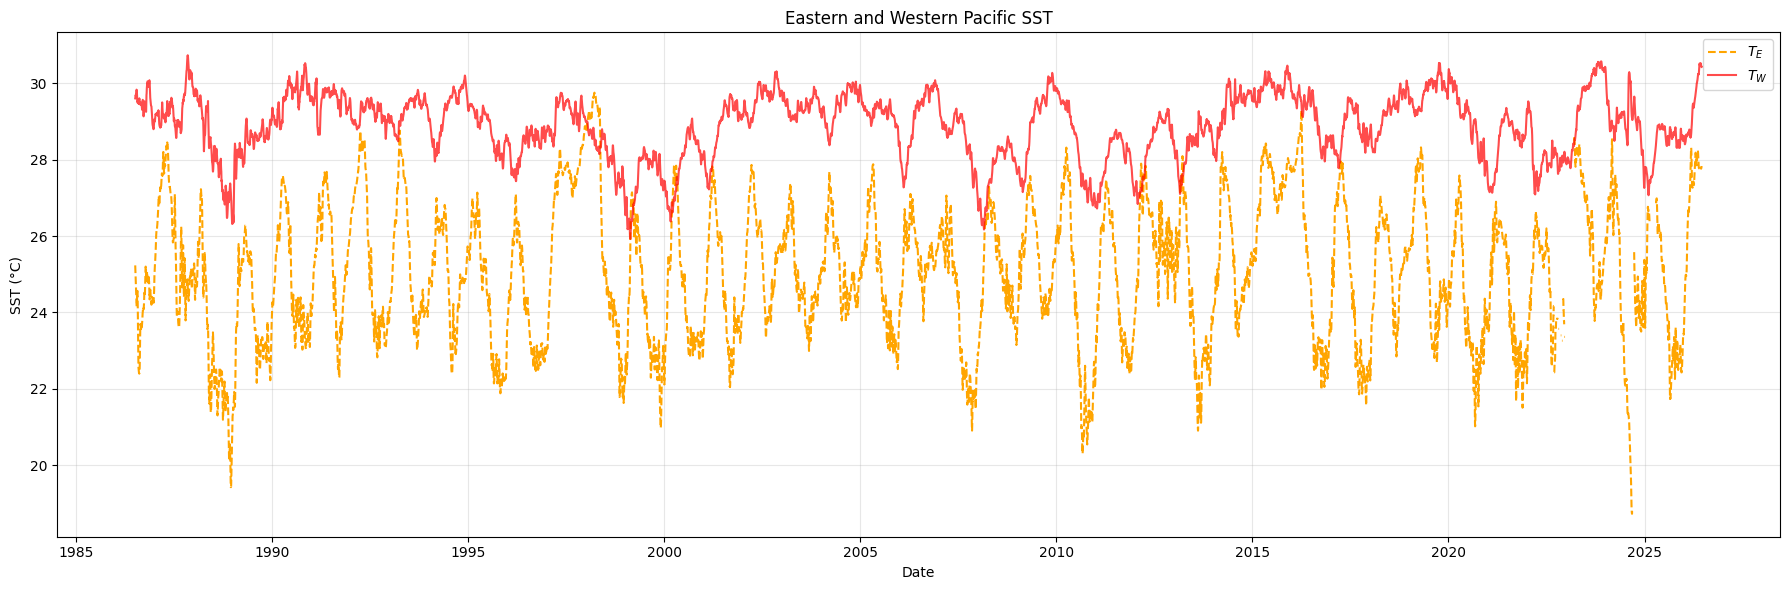

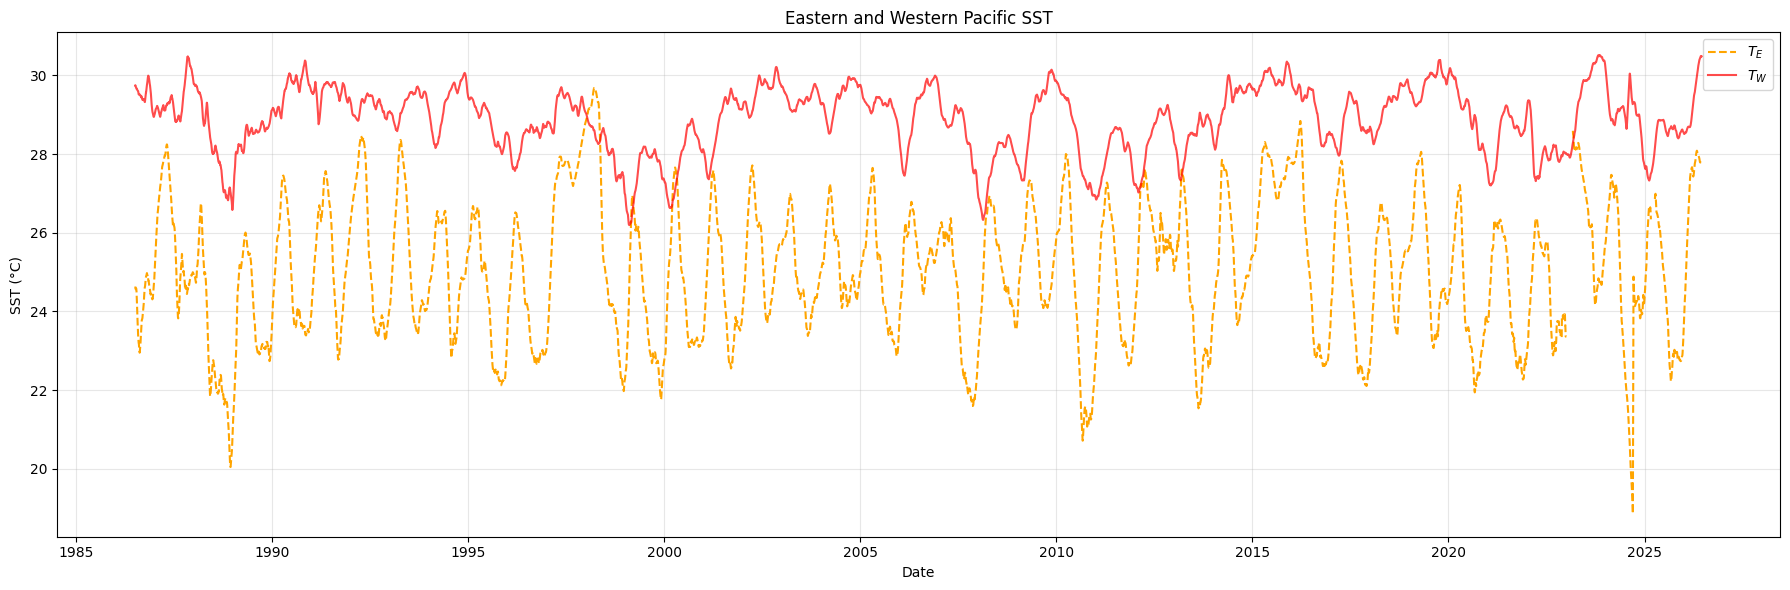

In [165]:
plot_sst(enso_common, "common")

plot_sst(enso_roll7, "roll7")

plot_sst(enso_roll30, "roll30")

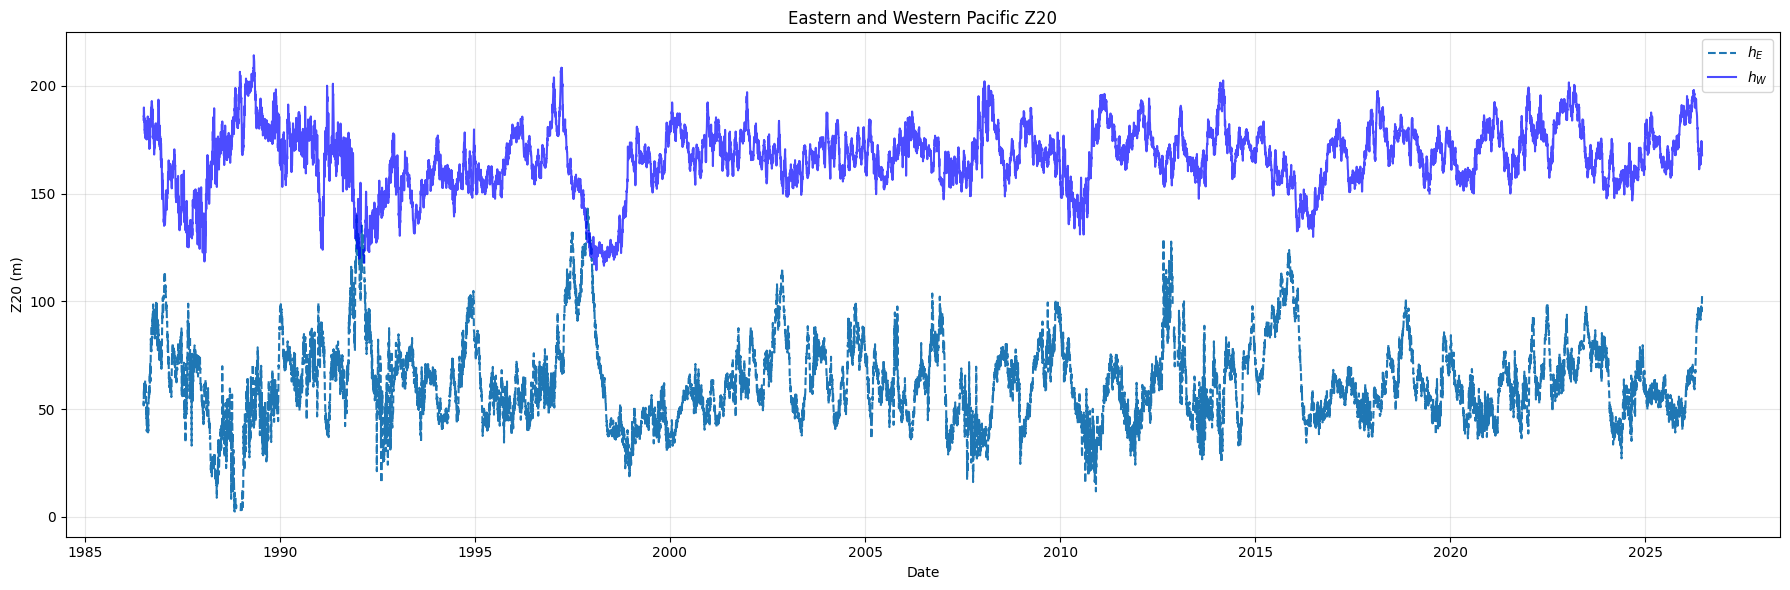

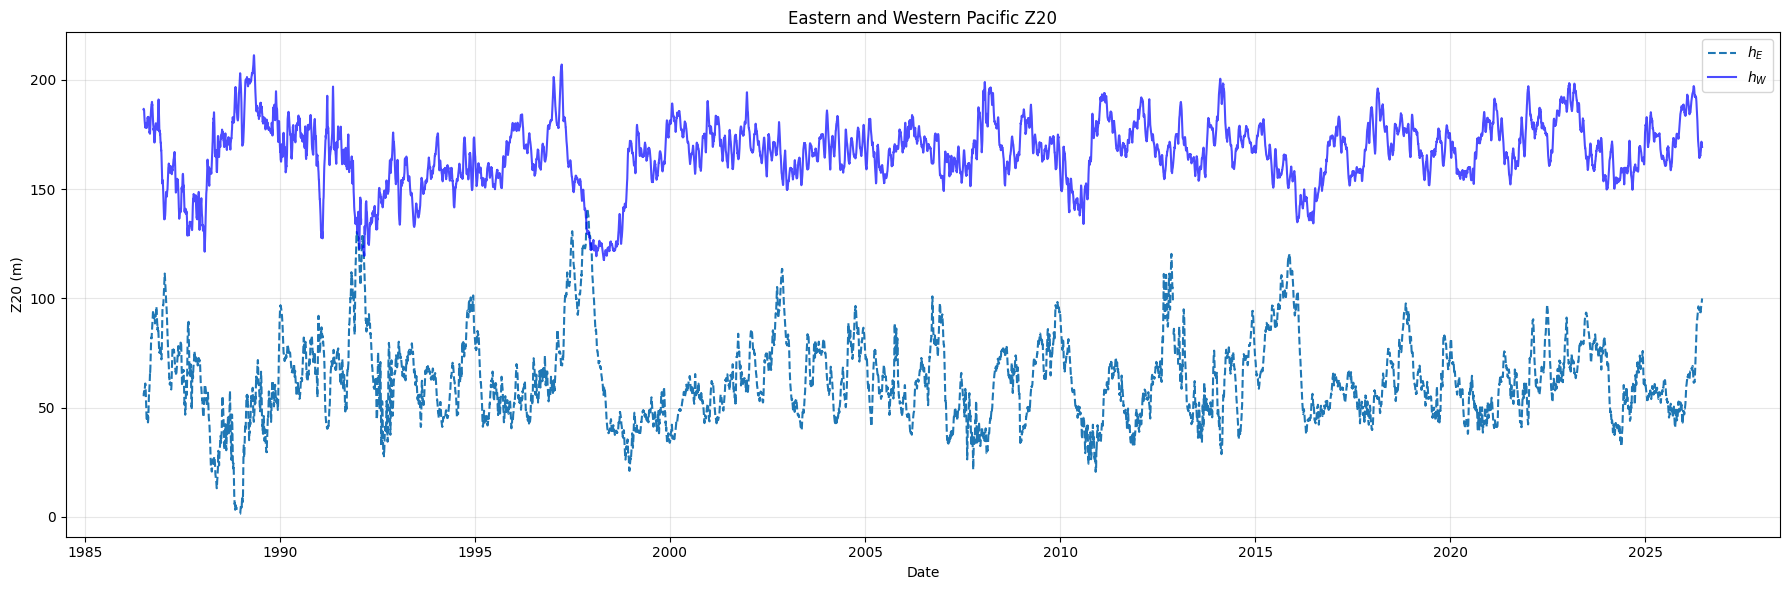

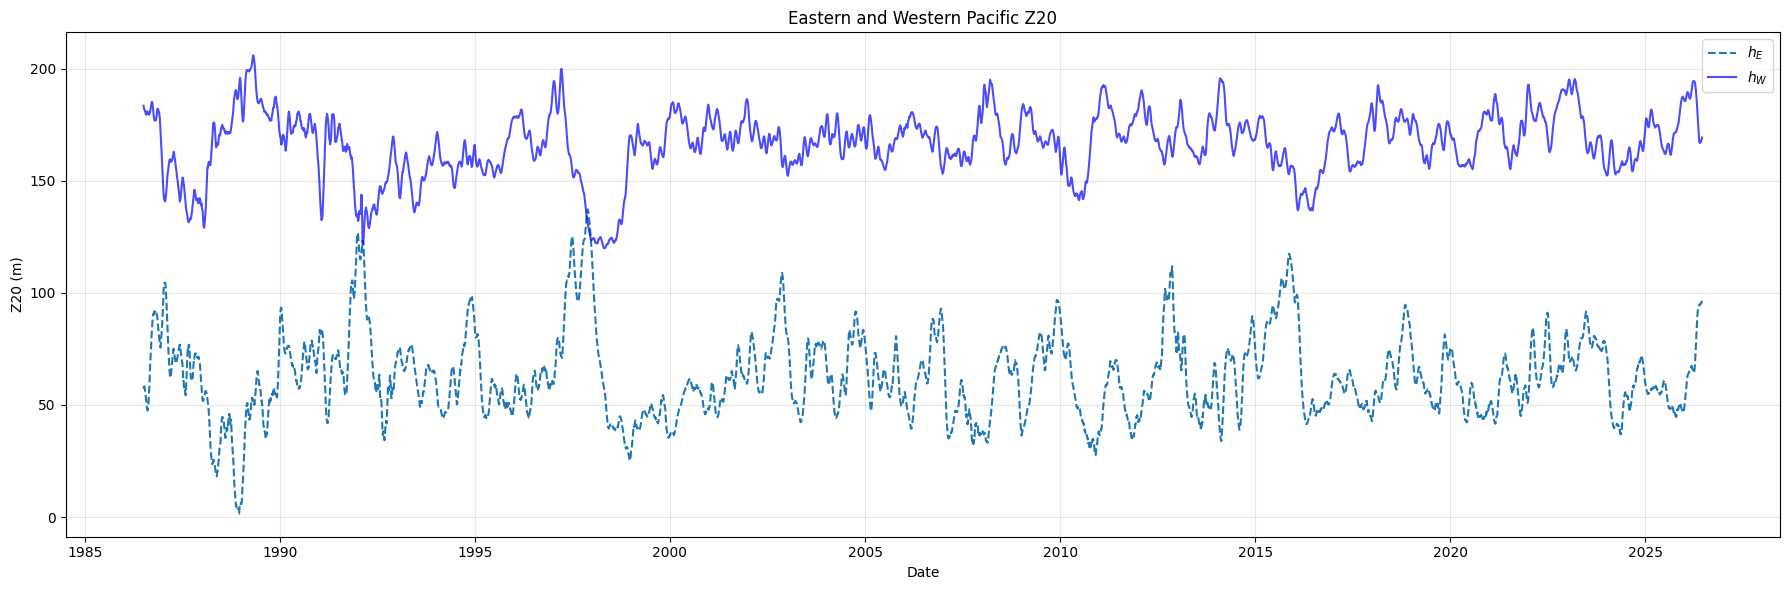

In [166]:
plot_z20(enso_common, "common")

plot_z20(enso_roll7, "roll7")

plot_z20(enso_roll30, "roll30")

In [154]:
for col in enso_common.columns[1:]:

    gap = ( enso_common.loc[  enso_common[col].notna(),  "date" ] .diff()  )

    print(f"\n{col}")

    print(gap.value_counts().head(10))


west_t
date
1 days    14568
2 days        9
7 days        1
Name: count, dtype: int64

west_h
date
1 days     14538
2 days         6
23 days        1
4 days         1
3 days         1
6 days         1
7 days         1
Name: count, dtype: int64

east_t
date
1 days     14290
2 days         7
3 days         3
7 days         1
9 days         1
6 days         1
13 days        1
14 days        1
21 days        1
11 days        1
Name: count, dtype: int64

east_h
date
1 days     14481
2 days         8
3 days         2
38 days        1
10 days        1
27 days        1
8 days         1
7 days         1
Name: count, dtype: int64


In [155]:
for col in enso_common.columns :

    dates = enso_common.loc[ enso_common[col].notna(), "date" ].reset_index(drop=True)

    gap = dates.diff()

    for i in range(1, len(dates)):

        if gap.iloc[i] > pd.Timedelta(days=1):

            print( f"{dates.iloc[i-1]} -> {dates.iloc[i]} ({gap.iloc[i].days} days)" )

    print(100*"==")

2021-03-09 00:00:00 -> 2021-03-16 00:00:00 (7 days)
1986-10-13 00:00:00 -> 1986-10-15 00:00:00 (2 days)
1986-10-15 00:00:00 -> 1986-10-17 00:00:00 (2 days)
1988-05-04 00:00:00 -> 1988-05-06 00:00:00 (2 days)
1988-05-10 00:00:00 -> 1988-05-12 00:00:00 (2 days)
1988-05-12 00:00:00 -> 1988-05-14 00:00:00 (2 days)
2019-06-22 00:00:00 -> 2019-06-24 00:00:00 (2 days)
2020-07-07 00:00:00 -> 2020-07-09 00:00:00 (2 days)
2020-07-09 00:00:00 -> 2020-07-11 00:00:00 (2 days)
2020-11-04 00:00:00 -> 2020-11-06 00:00:00 (2 days)
2021-03-09 00:00:00 -> 2021-03-16 00:00:00 (7 days)
1986-10-13 00:00:00 -> 1986-10-15 00:00:00 (2 days)
1986-10-15 00:00:00 -> 1986-10-17 00:00:00 (2 days)
1992-01-28 00:00:00 -> 1992-02-20 00:00:00 (23 days)
1992-02-21 00:00:00 -> 1992-02-25 00:00:00 (4 days)
1992-02-25 00:00:00 -> 1992-02-28 00:00:00 (3 days)
1992-02-29 00:00:00 -> 1992-03-06 00:00:00 (6 days)
2019-06-22 00:00:00 -> 2019-06-24 00:00:00 (2 days)
2020-07-07 00:00:00 -> 2020-07-09 00:00:00 (2 days)
2020-07-09 

## Correlation Matrix

In [83]:
corr = enso_common.drop(columns="date").corr()

corr.round(2)

,west_t,west_h,east_t,east_h
west_t,1.00,-0.29,0.20,0.51
west_h,-0.29,1.00,-0.16,-0.21
east_t,0.20,-0.16,1.00,0.43
east_h,0.51,-0.21,0.43,1.00


In [84]:
max_lag = 365

lags = range(-max_lag, max_lag + 1)

east_corr = [enso_common["east_t"].corr(enso_common["east_h"].shift(lag)) for lag in lags]

west_corr = [enso_common["west_t"].corr(enso_common["west_h"].shift(lag)) for lag in lags]

hw_te_corr = [enso_common["east_t"].corr(enso_common["west_h"].shift(lag)) for lag in lags]

he_tw_corr = [enso_common["west_t"].corr(enso_common["east_h"].shift(lag)) for lag in lags]

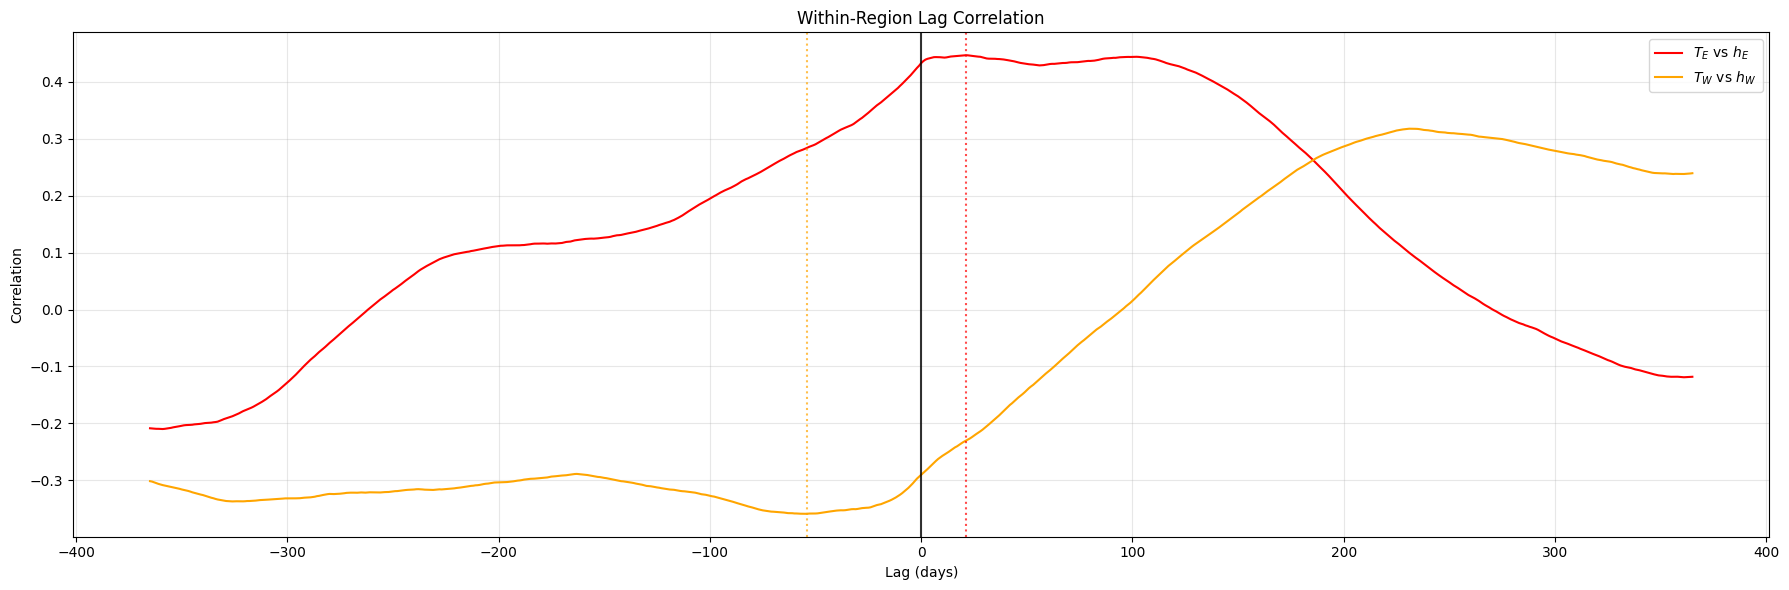

T_E => h_E : 21 days (0.447)
T_W => h_W : -54 days (-0.359)


In [85]:
east_peak = np.nanargmax(np.abs(east_corr))
west_peak = np.nanargmax(np.abs(west_corr))

east_lag = lags[east_peak]
west_lag = lags[west_peak]

plt.figure(figsize=(18, 6))

plt.plot(lags, east_corr, color="red", label=r"$T_E$ vs $h_E$")
plt.plot(lags, west_corr, color="orange", label=r"$T_W$ vs $h_W$")

plt.axvline(0, color="black", alpha=0.8)

plt.axvline(east_lag, color="red", linestyle=":", alpha=0.7)
plt.axvline(west_lag, color="orange", linestyle=":", alpha=0.7)

plt.title("Within-Region Lag Correlation")

plt.xlabel("Lag (days)")
plt.ylabel("Correlation")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "within_lag_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"T_E => h_E : {east_lag} days ({east_corr[east_peak]:.3f})")
print(f"T_W => h_W : {west_lag} days ({west_corr[west_peak]:.3f})")

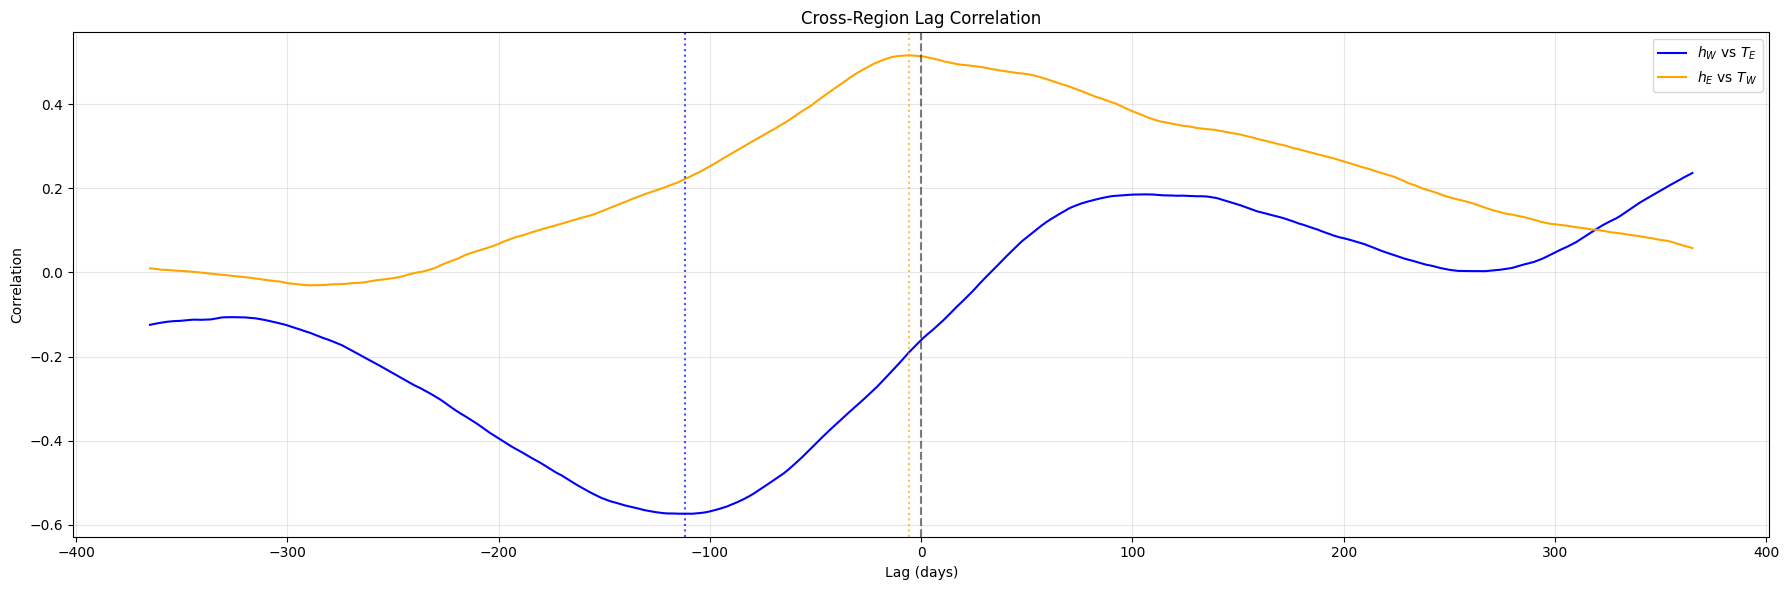

h_W → T_E : -112 days (-0.574)
h_E → T_W : -6 days (0.516)


In [86]:
hw_te_peak = np.nanargmax(np.abs(hw_te_corr))
he_tw_peak = np.nanargmax(np.abs(he_tw_corr))

hw_te_lag = lags[hw_te_peak]
he_tw_lag = lags[he_tw_peak]

plt.figure(figsize=(18, 6))

plt.plot(lags, hw_te_corr, color="blue", label=r"$h_W$ vs $T_E$")
plt.plot(lags, he_tw_corr, color="orange", label=r"$h_E$ vs $T_W$")

plt.axvline(0, color="black", linestyle="--", alpha=0.5)

plt.axvline(hw_te_lag, color="blue", linestyle=":", alpha=0.7)
plt.axvline(he_tw_lag, color="orange", linestyle=":", alpha=0.7)

plt.title("Cross-Region Lag Correlation")

plt.xlabel("Lag (days)")
plt.ylabel("Correlation")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "cross_lag_correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"h_W → T_E : {hw_te_lag} days ({hw_te_corr[hw_te_peak]:.3f})")
print(f"h_E → T_W : {he_tw_lag} days ({he_tw_corr[he_tw_peak]:.3f})")

### Lag Analysis Summary

The within-region analysis showed moderate coupling between SST and Z20, with the Eastern Pacific exhibiting a stronger positive relationship than the Western Pacific. The cross-region analysis revealed a stronger delayed relationship between $h_W$ and $T_E$, which is consistent with the recharge oscillator framework used in ENSO studies.

- $T_E \leftrightarrow h_E$: strongest relationship at 22 days ($r=0.484$)
- $T_W \leftrightarrow h_W$: strongest relationship at -54 days ($r=-0.359$)
- $h_W \leftrightarrow T_E$: strongest relationship at -112 days ($r=-0.573$)
- $h_E \leftrightarrow T_W$: strongest relationship at -6 days ($r=0.516$)

The stronger delayed coupling between $h_W$ and $T_E$ suggests that subsurface variations in the western Pacific may precede changes in eastern Pacific SST, supporting the physical basis of the recharge oscillator mechanism.

## Missing Value Assessment

In [144]:
enso_common.isna().sum()

date        0
west_t      9
west_h     38
east_t    275
east_h     91
dtype: int64

In [158]:
enso_hw_te = enso_common[
    ["date", "west_h", "east_t"]
].copy()

enso_hw_te.isna().sum()

date        0
west_h     38
east_t    275
dtype: int64

In [160]:
enso_hw_te.iloc[:, 1:] = (
    enso_hw_te.iloc[:, 1:]
    .interpolate(
        method="linear",
        limit=14
    )
)

enso_hw_te.isna().sum()

date        0
west_h      8
east_t    142
dtype: int64

In [161]:
for col in enso_hw_te.columns :

    dates = enso_hw_te.loc[ enso_hw_te[col].notna(), "date" ].reset_index(drop=True)

    gap = dates.diff()

    for i in range(1, len(dates)):

        if gap.iloc[i] > pd.Timedelta(days=1):

            print( f" {col} : { dates.iloc[i-1]} -> {dates.iloc[i]} ({gap.iloc[i].days} days)" )

    print(100*"==")

 date : 2021-03-09 00:00:00 -> 2021-03-16 00:00:00 (7 days)
 west_h : 1992-02-11 00:00:00 -> 1992-02-20 00:00:00 (9 days)
 west_h : 2021-03-09 00:00:00 -> 2021-03-16 00:00:00 (7 days)
 east_t : 2021-03-09 00:00:00 -> 2021-03-16 00:00:00 (7 days)
 east_t : 2022-11-08 00:00:00 -> 2022-11-15 00:00:00 (7 days)
 east_t : 2023-01-02 00:00:00 -> 2023-03-19 00:00:00 (76 days)
 east_t : 2024-09-18 00:00:00 -> 2024-09-29 00:00:00 (11 days)
 east_t : 2025-02-28 00:00:00 -> 2025-04-21 00:00:00 (52 days)


In [162]:
enso_hw_te.to_csv(
    PROCESS / "enso_hw_te_interp14.csv",
    index=False
)

In [156]:
enso_interp = enso_common.copy()

enso_interp.iloc[:, 1:] = (
    enso_interp.iloc[:, 1:]
    .interpolate(
        method="linear",
        limit=7
    )
)

enso_interp.isna().sum()

date        0
west_t      0
west_h     15
east_t    187
east_h     51
dtype: int64

In [157]:
for col in enso_interp.columns :

    dates = enso_interp.loc[ enso_interp[col].notna(), "date" ].reset_index(drop=True)

    gap = dates.diff()

    for i in range(1, len(dates)):

        if gap.iloc[i] > pd.Timedelta(days=1):

            print( f" {col} : { dates.iloc[i-1]} -> {dates.iloc[i]} ({gap.iloc[i].days} days)" )

    print(100*"==")

 date : 2021-03-09 00:00:00 -> 2021-03-16 00:00:00 (7 days)
 west_t : 2021-03-09 00:00:00 -> 2021-03-16 00:00:00 (7 days)
 west_h : 1992-02-04 00:00:00 -> 1992-02-20 00:00:00 (16 days)
 west_h : 2021-03-09 00:00:00 -> 2021-03-16 00:00:00 (7 days)
 east_t : 2021-03-09 00:00:00 -> 2021-03-16 00:00:00 (7 days)
 east_t : 2022-09-13 00:00:00 -> 2022-09-15 00:00:00 (2 days)
 east_t : 2022-10-04 00:00:00 -> 2022-10-10 00:00:00 (6 days)
 east_t : 2022-10-18 00:00:00 -> 2022-10-25 00:00:00 (7 days)
 east_t : 2022-11-01 00:00:00 -> 2022-11-15 00:00:00 (14 days)
 east_t : 2022-11-22 00:00:00 -> 2022-11-26 00:00:00 (4 days)
 east_t : 2022-12-03 00:00:00 -> 2022-12-06 00:00:00 (3 days)
 east_t : 2022-12-26 00:00:00 -> 2023-03-19 00:00:00 (83 days)
 east_t : 2024-09-11 00:00:00 -> 2024-09-29 00:00:00 (18 days)
 east_t : 2025-02-21 00:00:00 -> 2025-04-21 00:00:00 (59 days)
 east_h : 1988-11-26 00:00:00 -> 1988-12-27 00:00:00 (31 days)
 east_h : 2012-11-27 00:00:00 -> 2012-11-30 00:00:00 (3 days)
 eas

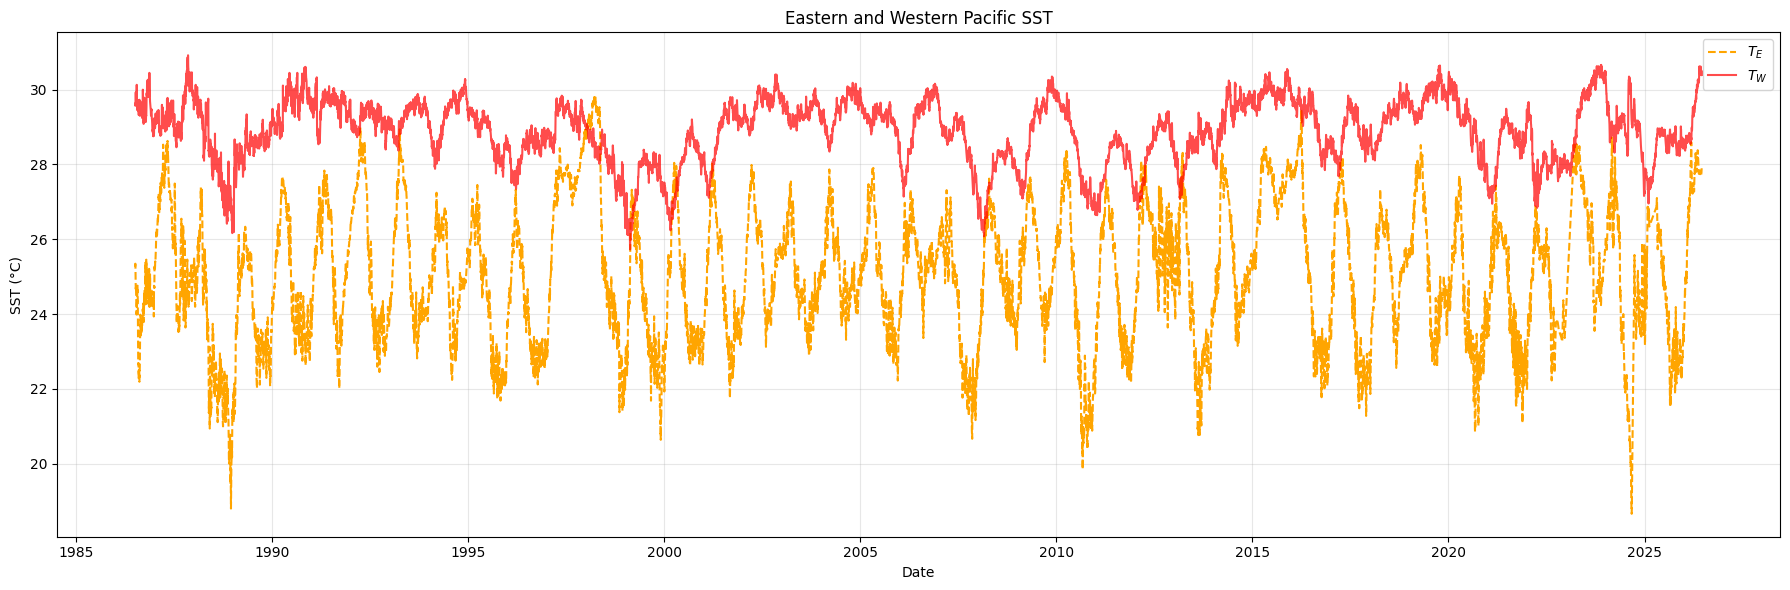

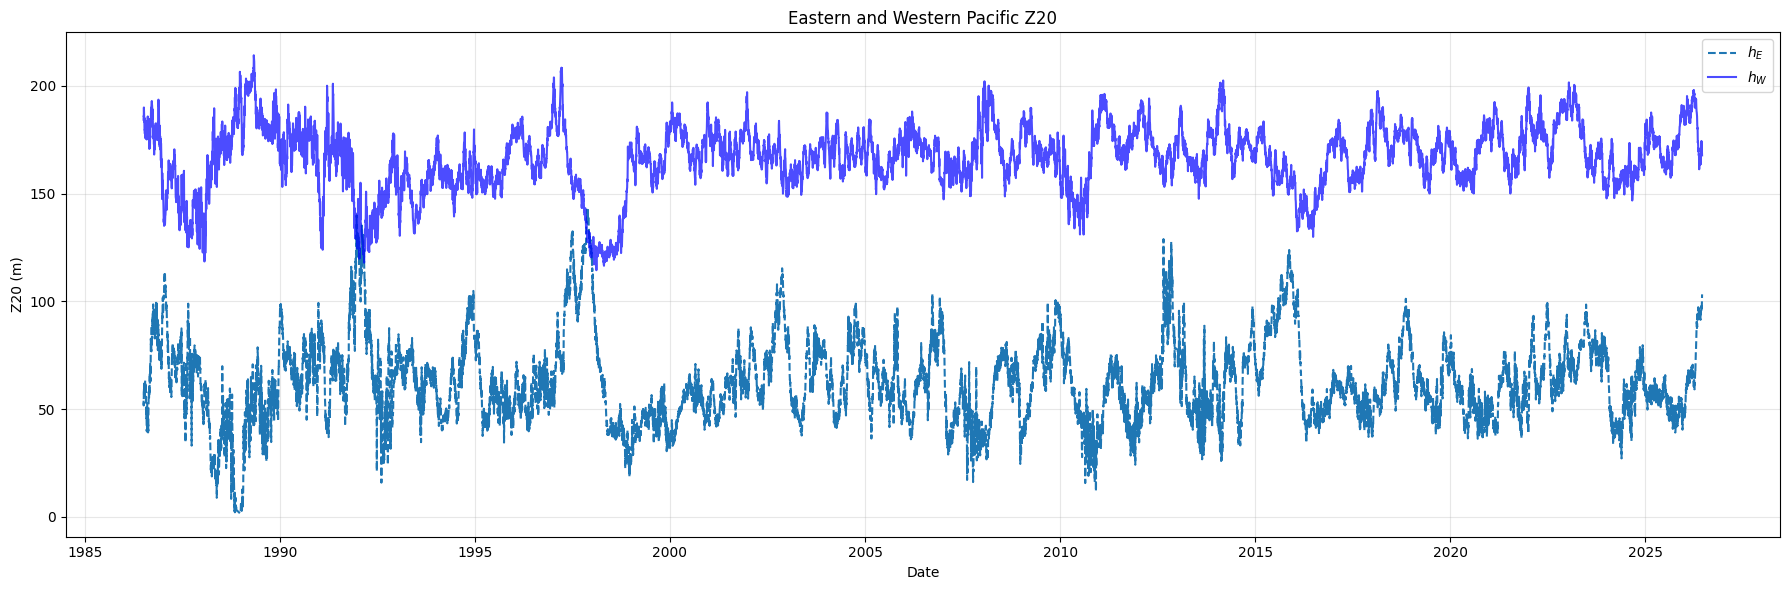

In [153]:
plot_sst(enso_interp, "interp")
plot_z20(enso_interp, "interp")

## Spectral Analysis

In [46]:
freq_te, power_te = periodogram(enso_dataset["east_t"].dropna())

freq_tw, power_tw = periodogram(enso_dataset["west_t"].dropna())

In [50]:
freq_te, power_te = periodogram(
    enso_dataset["east_t"].dropna(),
    detrend="linear"
)

freq_tw, power_tw = periodogram(
    enso_dataset["west_t"].dropna(),
    detrend="linear"
)

In [49]:
print(freq_te.min(), freq_te.max())

0.0 0.5


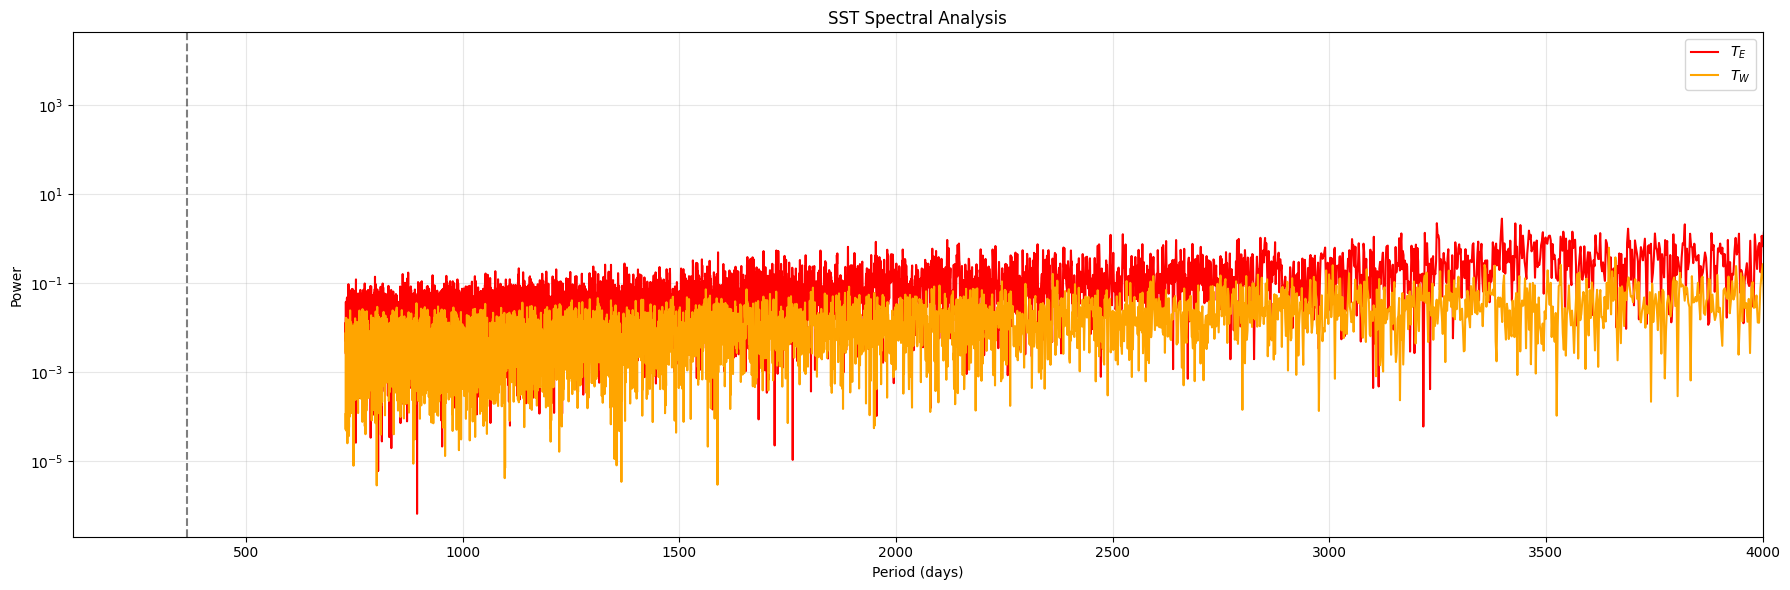

In [51]:
freq_te, power_te = periodogram(
    enso_dataset["east_t"].dropna(),
    detrend="linear"
)

freq_tw, power_tw = periodogram(
    enso_dataset["west_t"].dropna(),
    detrend="linear"
)

period_te = 365 / freq_te[1:]
period_tw = 365 / freq_tw[1:]

plt.figure(figsize=(18, 6))

plt.plot(
    period_te,
    power_te[1:],
    color="red",
    label=r"$T_E$"
)

plt.plot(
    period_tw,
    power_tw[1:],
    color="orange",
    label=r"$T_W$"
)

plt.axvline(
    365,
    color="black",
    linestyle="--",
    alpha=0.5
)

plt.xlim(100, 4000)

plt.yscale("log")

plt.title("SST Spectral Analysis")

plt.xlabel("Period (days)")

plt.ylabel("Power")

plt.legend()

plt.grid(alpha=0.3)

plt.tight_layout()

plt.savefig(
    IMAGE_DIR / "sst_spectral_analysis.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()